# Desnowing Visualization and Results


In [20]:
%matplotlib inline
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import sys
import json

# Thêm đường dẫn tới thư mục gốc ProjectCV
sys.path.append('A:/HUST_on_GitHub/ProjectCV')

from ultralytics import YOLO
from src.restoration.morph_guided_desnow import MorphGuidedDesnowFilter, MorphGuidedDesnowConfig
import dataclasses


In [21]:
def load_cfg(path):
    if not os.path.exists(path):
        return None
    with open(path, 'r') as f:
        cfg = yaml.safe_load(f)
    if not cfg:
        return {}
    
    valid_keys = {field.name for field in dataclasses.fields(MorphGuidedDesnowConfig)}
    return {k: v for k, v in cfg.items() if k in valid_keys}

# Load configs
configs = {
    "Default": MorphGuidedDesnowConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/configs/desnow_morph_guided_default.yaml')),
    "Optuna_SSIM": MorphGuidedDesnowConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/desnow_config1_ssim/best_config.yaml')) if load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/desnow_config1_ssim/best_config.yaml') is not None else None,
    "Optuna_BRISQUE": MorphGuidedDesnowConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/desnow_config2_brisque/best_config.yaml')) if load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/desnow_config2_brisque/best_config.yaml') is not None else None,
    "Optuna_mAP50": MorphGuidedDesnowConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/desnow_config3_map50/best_config.yaml')) if load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/desnow_config3_map50/best_config.yaml') is not None else None
}

# Tạo dictionary chứa các bộ lọc
filters = {k: MorphGuidedDesnowFilter(v) for k, v in configs.items() if v is not None}

# Tải YOLO model
yolo_model = YOLO('A:/HUST_on_GitHub/ProjectCV/yolo26n.pt')

print("Loaded filters:", list(filters.keys()))


Loaded filters: ['Default', 'Optuna_SSIM', 'Optuna_BRISQUE', 'Optuna_mAP50']


In [22]:
# Draw Ground Truth BB
def draw_gt_boxes(img, label_path):
    img_copy = img.copy()
    if not os.path.exists(label_path):
        return img_copy
        
    CLASS_NAMES = {
        0: "person",
        1: "bicycle",
        2: "car",
        3: "motorcycle",
        5: "bus",
        6: "train",
        7: "truck"
    }
    
    h, w = img_copy.shape[:2]
    with open(label_path, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            cls_id = int(parts[0])
            cls_name = CLASS_NAMES.get(cls_id, str(cls_id))
            
            x_center = float(parts[1]) * w
            y_center = float(parts[2]) * h
            box_w = float(parts[3]) * w
            box_h = float(parts[4]) * h
            
            x1 = int(x_center - box_w / 2)
            y1 = int(y_center - box_h / 2)
            x2 = int(x_center + box_w / 2)
            y2 = int(y_center + box_h / 2)
            
            cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 3)
            cv2.putText(img_copy, f"GT: {cls_name}", (x1, max(y1 - 5, 0)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
    return img_copy

def show_images_yolo(imgs, titles, figsize=(25, 5)):
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    if len(imgs) == 1: axes = [axes]
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=14, pad=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## 1.Metrics

In [23]:
eval_json = 'A:/HUST_on_GitHub/ProjectCV/results/desnow_evaluation/metrics.json'
if os.path.exists(eval_json):
    with open(eval_json, 'r') as f:
        results = json.load(f)
    df = pd.DataFrame(results).T
    display(df)
else:
    print("Chưa có file kết quả, hãy đảm bảo bạn đã chạy 07_eval_desnow_all_configs.py!")


,ssim,psnr,brisque,niqe,map50,map50_95
raw,0.804464,25.103091,36.566496,4.763971,0.056670,0.032019
default,0.803039,25.072089,37.206413,4.789157,0.056853,0.032092
config1,0.805996,25.631102,36.483593,4.739206,0.059413,0.033716
config2,0.611900,16.574683,33.839663,4.101686,0.060411,0.033304
config3,0.622534,17.602740,36.879157,4.216694,0.064811,0.035886


## 2. Restoration


--- Restore Visualization: winter_weather_05690.jpg ---


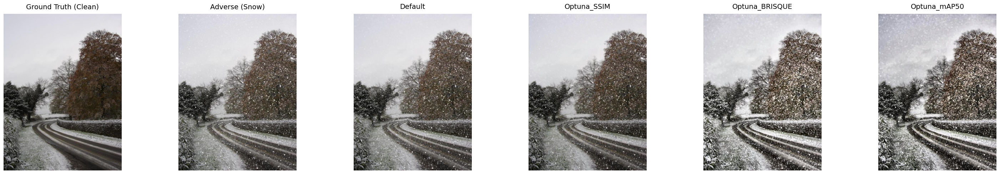


--- Restore Visualization: crossing_04767.jpg ---


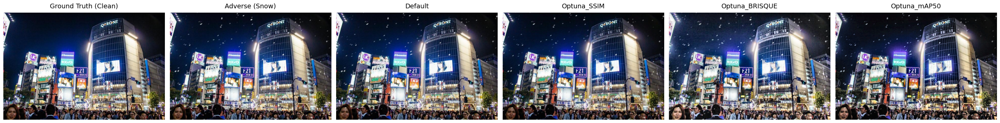


--- Restore Visualization: winter_tree_02115.jpg ---


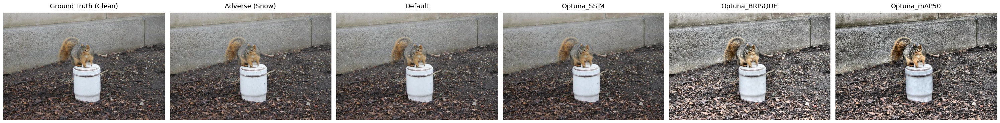


--- Restore Visualization: winter_japan_10605.jpg ---


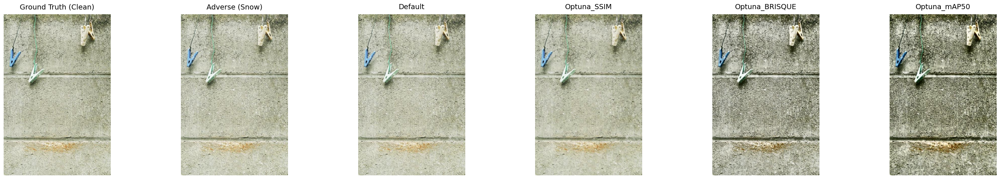


--- Restore Visualization: city_read_17478.jpg ---


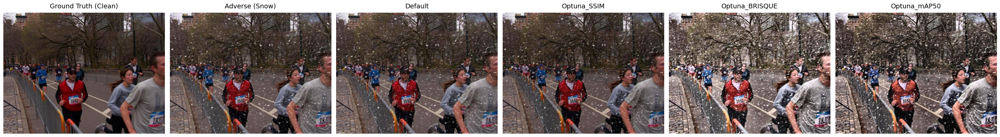

In [28]:
import glob
import random
import os
import cv2

# Sample 5 images from Snow100K để có ảnh Ground Truth Sạch.
splits_file = "A:/HUST_on_GitHub/ProjectCV/data/snow100k/splits/test.txt"
base_dir = "A:/HUST_on_GitHub/ProjectCV/dataset/Snow100K"

if os.path.exists(splits_file):
    with open(splits_file, 'r') as f:
        lines = f.readlines()
    random.seed(42)
    sample_pairs = random.sample(lines, min(5, len(lines)))
else:
    sample_pairs = []
    print("Tập test Snow100K không tồn tại!")

for line in sample_pairs:
    # File test.txt lưu cách nhau bằng dấu phẩy
    snow_rel, gt_rel = line.strip().split(',')
    
    # Gắn thêm đường dẫn gốc để thành đường dẫn tuyệt đối
    snow_path = os.path.join(base_dir, snow_rel)
    gt_path = os.path.join(base_dir, gt_rel)
    
    basename = os.path.basename(snow_path)
    print(f"\n==================================================")
    print(f"--- Restore Visualization: {basename} ---")
    
    img = cv2.imread(snow_path)
    img_gt = cv2.imread(gt_path)
    
    imgs_to_show = [img_gt, img]
    titles = ["Ground Truth (Clean)", "Adverse (Snow)"]
    
    # Qua từng filter (Default + Optuna Configs)
    for cfg_name, f_obj in filters.items():
        restored = f_obj.restore(img)
        imgs_to_show.append(restored)
        titles.append(cfg_name)

    show_images_yolo(imgs_to_show, titles, figsize=(5 * len(imgs_to_show), 5))


## 3. Detection


--- Detection Visualization: snow_storm-253.jpg ---


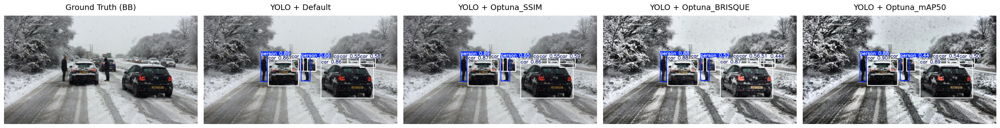


--- Detection Visualization: snow_storm-063.jpg ---


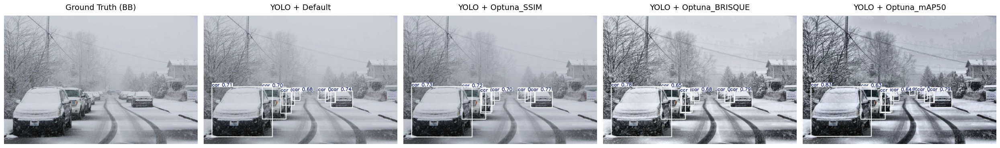


--- Detection Visualization: snow_storm-229.jpg ---


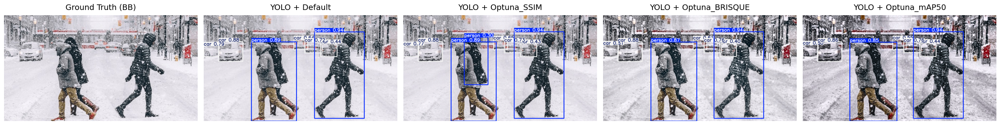


--- Detection Visualization: snow_storm-121.jpg ---


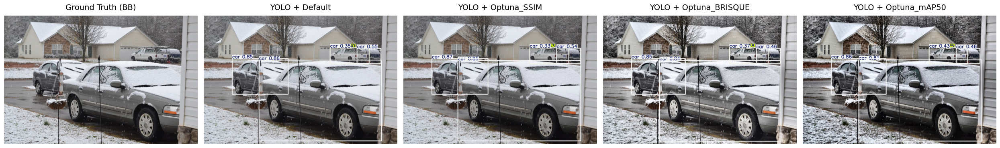


--- Detection Visualization: snow_storm-182.jpg ---


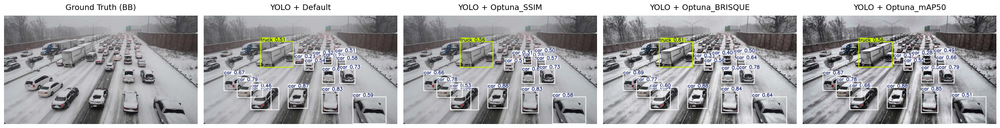

In [ ]:
# Sample 5 images từ DAWN Snow để vẽ Bounding Box
snow_dir = "A:/HUST_on_GitHub/ProjectCV/data/dawn/images/snow"
label_dir = "A:/HUST_on_GitHub/ProjectCV/data/dawn/labels_yolo/snow"

if os.path.exists(snow_dir):
    all_images = glob.glob(os.path.join(snow_dir, "*.jpg"))
    random.seed(101) # Khác seed để đa dạng hóa
    sample_images = random.sample(all_images, min(5, len(all_images)))
else:
    sample_images = []

for img_path in sample_images:
    basename = os.path.basename(img_path)
    label_path = os.path.join(label_dir, basename.replace('.jpg', '.txt'))
    
    img = cv2.imread(img_path)
    if img is None: continue
    
    print(f"\n==================================================")
    print(f"--- Detection Visualization: {basename} ---")

    # Vẽ Ground Truth Box
    gt_img = draw_gt_boxes(img, label_path)
    
    imgs_to_show = [gt_img]
    titles = ["Ground Truth (BB)"]
    
    # Chạy YOLO trên từng filter Output
    for cfg_name, f_obj in filters.items():
        restored = f_obj.restore(img)  # <--- Sửa ở đây
        # Chạy dự đoán, YOLO model đã tải từ cell 2
        res = yolo_model.predict(restored, verbose=False, classes=[0, 1, 2, 3, 5, 6, 7])[0]
        res_img = res.plot()
        imgs_to_show.append(res_img)
        titles.append(f"YOLO + {cfg_name}")
        
    show_images_yolo(imgs_to_show, titles, figsize=(5 * len(imgs_to_show), 5))
